# PMoA selection for 2,4-D in *D. pictus*

This summarizes effects implied by the alternative PMoAs $G$ and $M$. <br>
We do not consider PMoA $\kappa^-$ here because the implied effect on metamorphosis timing was very similar to that of $G$.

## Notebook setup

In [1]:
using DrWatson
@quickactivate "."
const SAVETAG_LARVALFIT = "input/Discoglossus_larvae" # directory from which larval/metamorph parameters are loaded
const SAVETAG_JUVENILEFIT = "input/Discoglossus_juveniles" # directory from which juvenile/adult parameters are loaded
const SAVETAG_TKTDFIT = "Discoglossus_24D"
const SAVETAG = "Discoglossus_24D_exp2_modelaveraging"

using Revise

includet(scriptsdir("ModelFitting_Discoglossus_24D_Ugent_exp2.jl"))

p_opt_control, p_opt_M, p_opt_G = reference_param_estims()

((spc.Z_mean_Ugent = 0.51, spc.eta_AS_juv = 0.73), [1.374, 0.065, 3.65], [0.22, 0.29, 4.54])

In [ ]:
# setting up ModelFit instances for both PMoAs
fG = setup_modelfit_exp2_noBd("G"; p_opt_control = p_opt_control);
fM = setup_modelfit_exp2_noBd("M"; p_opt_control = p_opt_control);

┌ Warning: Did not find spc.Z_mean_Ugent in parameter vector - skipping.
└ @ EcotoxModelFitting C:\Users\simon\.julia\packages\EcotoxModelFitting\aC0gq\src\assign.jl:12
┌ Info: 
│         Estimating 3 parameters: 
│         ["spc.KD[1,1]", "spc.E[1,1]", "spc.B[1,1]"]
│         
└ @ EcotoxModelFitting C:\Users\simon\.julia\packages\EcotoxModelFitting\aC0gq\src\modelfit.jl:77
┌ Info: Normalizing data weights
└ @ EcotoxModelFitting C:\Users\simon\.julia\packages\EcotoxModelFitting\aC0gq\src\modelfit.jl:145
┌ Info: No column `observation_weight` found in data key juveniles_control. Assuming uniform weights.
└ @ EcotoxModelFitting C:\Users\simon\.julia\packages\EcotoxModelFitting\aC0gq\src\modelfit.jl:98
┌ Info: No column `observation_weight` found in data key juveniles. Assuming uniform weights.
└ @ EcotoxModelFitting C:\Users\simon\.julia\packages\EcotoxModelFitting\aC0gq\src\modelfit.jl:98
┌ Info: No column `observation_weight` found in data key juveniles_agg. Assuming uniform weights.
└

In [23]:
sim_G = [fG.simulator(p_opt_G) for _ in 1:100]
sim_M = [fM.simulator(p_opt_M) for _ in 1:100];

## Comparing effects in growth

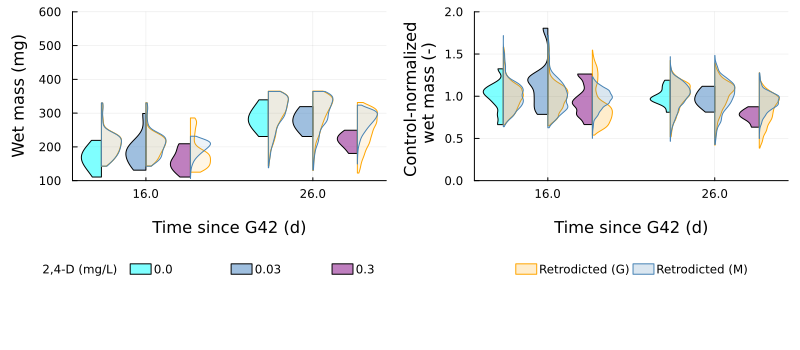

In [ ]:
juveniles = vcat(
    @transform(EcotoxModelFitting.extract_simkey(sim_G, :juveniles), :pmoa = "G"),
    @transform(EcotoxModelFitting.extract_simkey(sim_M, :juveniles), :pmoa = "M")
)

exp2 = load_data_exp2_noBd()

plt1 = @df @subset(exp2[:juveniles], :treatment_bd .== "uninfected") groupedviolin(
    string.(:t_since_mm), :wetmass_mg, group = :pretreatment_24D, 
    side = :left,
    legend = :outerbottom, legend_column = -1,
    legendtitle = "2,4-D (mg/L)", legendtitlefontsize = 8,
    palette = palette([:cyan, :purple], 3), fillalpha = .5,
    xlabel = "\n Time since G42 (d) \n", ylabel = "Wet mass (mg)", 
    ylim = (100,600)
)
    
plt2 = @df @subset(exp2[:juveniles], :treatment_bd .== "uninfected") groupedviolin(
    string.(:t_since_mm), :y_wetmass_mg, group = :pretreatment_24D, 
    side = :left,
    legend = :outerbottom, legend_column = -1, 
    palette = palette([:cyan, :purple], 3), fillalpha = .5,
    xlabel = "\n Time since G42 (d) \n", ylabel = "Control-normalized \n wet mass (-)", 
    ylim = (0,2), 
    label = ""
)

plt = plot(
        plt1, plt2, 
        lqyout = (1,2), size = (800,350), 
        bottommargin = 5mm, leftmargin = 5mm,
        legend_background_color = :transparent,
        foreground_color_legend = nothing
        )


plot!(plt, subplot = 2, label = "")

@df @subset(juveniles, :pmoa .== "G") groupedviolin!(    
    string.(:t_since_mm), :wetmass_mg,
    group = :pretreatment_24D,
    side = :right,
    color = :orange, 
    linecolor = :orange, 
    label = "", 
    fillalpha = .1,
    subplot = 1
)

@df @subset(juveniles, :pmoa .== "M") groupedviolin!(    
    string.(:t_since_mm), :wetmass_mg,
    group = :pretreatment_24D,
    side = :right,
    color = :steelblue, 
    linecolor = :steelblue, 
    label = "", 
    fillalpha = .1,
    subplot = 1
)


@df @subset(juveniles, :pmoa .== "G") groupedviolin!(
    plt,
    string.(:t_since_mm), :y_wetmass_mg,
    group = :pretreatment_24D,
    side = :right,
    color = :orange, 
    linecolor = :orange, 
    fillalpha = .2,
    label = ["Retrodicted (G)" "" ""], 
    subplot = 2
)

@df @subset(juveniles, :pmoa .== "M") groupedviolin!(
    plt,
    string.(:t_since_mm), :y_wetmass_mg,
    group = :pretreatment_24D,
    side = :right,
    color = :steelblue, 
    linecolor = :steelblue, 
    fillalpha = .2,
    subplot = 2, 
    leg = :outerbottom, 
    label = ["Retrodicted (M)" "" ""]
)


savefig(plot(plt, dpi = 300), datadir("sims", SAVETAG, "VPC_bestfit_PMoA=average.png"))

plt

## Comparing effects on metamorphosis timing

In [82]:
sim_raw_G = [@transform(fG.simulator(p_opt_G; return_raw = true), :num_sim = i) for i in 1:10] |> x-> vcat(x...) |> x-> @transform(x, :pmoa = "G")
sim_raw_M = [@transform(fM.simulator(p_opt_M; return_raw = true), :num_sim = i) for i in 1:10] |> x-> vcat(x...) |> x-> @transform(x, :pmoa = "M")

sim = vcat(sim_raw_G, sim_raw_M);

sim[!,:treatment_24D] = [TREATMENT_MAP[t] for t in sim.treatment_id]
retrodicted_mm_timing = @chain sim begin
    combine(groupby(_, [:replicate, :treatment_24D, :pmoa, :num_sim])) do df
        DataFrame(
            tsincehatch_G42 = metamorphosis_timing(df)[1]
        )
    end  
    EcotoxSystems.relative_response(
        [:tsincehatch_G42], 
        :treatment_24D; 
        groupby_vars = [:pmoa, :num_sim]
    )
    #begin
    #    ref = _[_.treatment_24D .== 0,:tsincehatch_G42] |> mean
    #    @transform(_, :y_tsincehatch_G42 = :tsincehatch_G42 ./ ref)
    #end
end ;

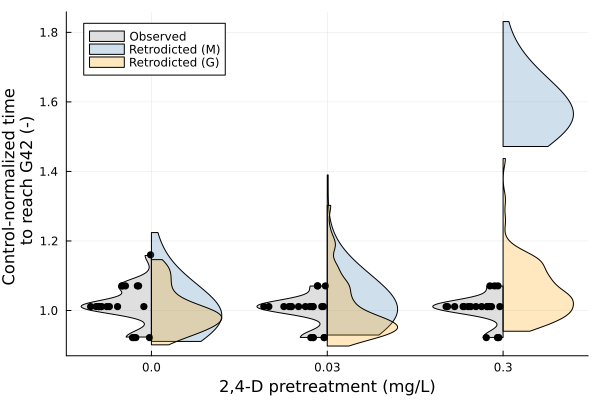

In [90]:



# plotting observed + retrodicted timing of mm
# reading observed effects on mm timing 
exp1_metamorphosis_timing = @chain CSV.read(datadir("exp_raw", "UGent", "exp1", "metamorphosis_timing.csv"), DataFrame) begin
    begin
        tsincehatch_ref = @subset(_, :treatment_24D .== 0).tsincehatch_G42 |> skipmissing |> mean
        @transform(_, :y_tsincehatch_G42 = :tsincehatch_G42 ./ tsincehatch_ref)
    end
end

# plotting observed effects on mm timing
plt = @df @subset(exp1_metamorphosis_timing, :treatment_bd .== "uninfected") violin(
    string.(:treatment_24D), :y_tsincehatch_G42; 
    fillalpha = .25, color = :gray, leg = :topleft, side = :left, label = "Observed", 
    xlabel = "2,4-D pretreatment (mg/L)", ylabel = "Control-normalized time \n to reach G42 (-)"
)

@df @subset(exp1_metamorphosis_timing, :treatment_bd .== "uninfected") dotplot!(
      string.(:treatment_24D), :y_tsincehatch_G42, 
      side = :left, color = :black, label = ""
)

# plotting retrodicted effects
@df @subset(retrodicted_mm_timing, :pmoa .== "M") violin!(
    string.(:treatment_24D), :y_tsincehatch_G42, 
    fillalpha = .25, color = :steelblue, label = "Retrodicted (M)", side = :right
)


@df @subset(retrodicted_mm_timing, :pmoa .== "G") violin!(
    string.(:treatment_24D), :y_tsincehatch_G42, 
    fillalpha = .25, color = :orange, label = "Retrodicted (G)", side = :right
)


savefig(plot(plt, dpi = 300), datadir("sims", SAVETAG, "VPC_bestfit_tsincehatch_G42_PMoA=average.png"))

display(plt)
